In [6]:
import cv2
import tifffile as tiff
import numpy as np
import os
from tqdm import tqdm
import shutil
import matplotlib.pyplot as plt

In [7]:
data = np.load("/mnt/d/01_Projects/CV/Water_Segmentation/Data/new_data/images/S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_image_0_2.npy")
data.shape

(256, 256, 12)

In [8]:
data.dtype

dtype('int16')

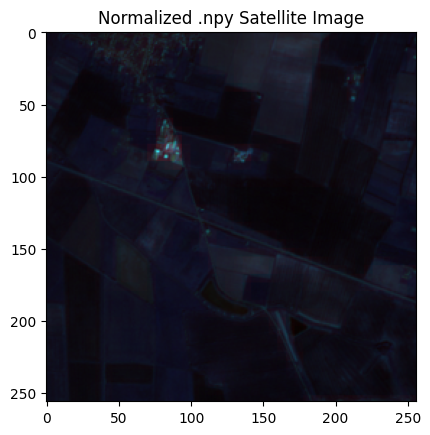

In [9]:
import matplotlib.pyplot as plt
if len(data.shape) == 3 and data.shape[-1] > 3:
    # It's a satellite image! Let's extract 3 channels (e.g., bands 0, 1, 2)
    display_img = data[:, :, :3] 
    
    # Normalize the massive numbers down to exactly 0.0 - 1.0
    display_img = (display_img - np.min(display_img)) / (np.max(display_img) - np.min(display_img) + 1e-8)
    
    plt.imshow(display_img)
    plt.title("Normalized .npy Satellite Image")

In [10]:
label = np.load("/mnt/d/01_Projects/CV/Water_Segmentation/Data/new_data/labels/S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_2.npy")
label.shape

(1, 256, 256)

In [11]:
label.dtype

dtype('int16')

In [12]:
label = label.squeeze()
label.shape

(256, 256)

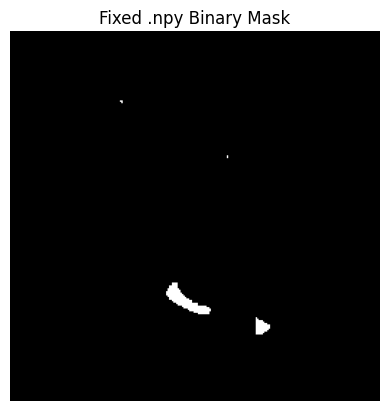

In [13]:

plt.imshow(label, cmap='gray')
plt.title("Fixed .npy Binary Mask")
plt.axis('off')
plt.show()

In [15]:
l1 = ["tamer", "nada", "ahmed"]
l2 = [22, 21, 9]
for x,y in zip(l1,l2):
    print(x,y)

tamer 22
nada 21
ahmed 9


In [16]:
for idx , name in enumerate(l1):
    print(idx, name)

0 tamer
1 nada
2 ahmed


In [17]:
for idx, (name,age) in enumerate(zip(l1,l2)):
    print(f"index: {idx} , Name: {name}, Age: {age}")

index: 0 , Name: tamer, Age: 22
index: 1 , Name: nada, Age: 21
index: 2 , Name: ahmed, Age: 9


In [1]:
NPY_IMAGES_DIR = '/mnt/d/01_Projects/CV/Water_Segmentation/Data/new_data/images' 
NPY_MASKS_DIR = '/mnt/d/01_Projects/CV/Water_Segmentation/Data/new_data/labels'

IMAGES_DIR = '/mnt/d/01_Projects/CV/Water_Segmentation/Data/old_data/images'
MASKS_DIR = '/mnt/d/01_Projects/CV/Water_Segmentation/Data/old_data/labels'



In [7]:
npy_img_files = sorted(os.listdir(NPY_IMAGES_DIR))
npy_mask_files = sorted(os.listdir(NPY_MASKS_DIR))

In [8]:
npy_mask_files

['S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_0.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_1.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_10.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_11.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_12.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_13.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_14.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_15.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_16.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_17.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_18.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_0_19.npy',
 'S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_2017040

In [9]:
type(npy_img_files) , type(npy_mask_files)

(list, list)

In [10]:
test_mask = np.load("/mnt/d/01_Projects/CV/Water_Segmentation/Data/new_data/labels/S2A_MSIL2A_20170409T105651_N0204_R094_T30UYC_20170409T110529_chip_41_37.npy")
test_mask

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=int16)

In [11]:
len(test_mask.shape)

3

In [10]:
for i, (img_name, mask_name) in enumerate(zip(npy_img_files, npy_mask_files)):
   # Test The output of the loop
   # print(f"the index{i} , Image Path: {npy_img_files[i]}, Mask_path: {npy_mask_files[i]}") 
   img_path = os.path.join(NPY_IMAGES_DIR, img_name)
   mask_path = os.path.join(NPY_MASKS_DIR, mask_name)
   img_arr = np.load(img_path)
   mask_arr = np.load(mask_path)
   # print(f"Image full path: {img_arr} | Mask full path: {mask_arr}")
   # Validate if the (Mask) has dimension of (1,256,256) convert it to (256,256)
   # Because OpenCV the imread expect it as 2D array not 3D
   # Second Validation Check if the Dim of the (Images) is (12,256,256) --> (256,256,12)
   # Because the  Tensorflow and Neural Network of the U-Net expect this dimension

   # Validate the Mask
   if mask_arr.shape[0] == 1 and len(mask_arr.shape) == 3:
      # Reduce the Dimension of 1
      mask_arr = mask_arr.squeeze()
   # Validate the Images
   if img_arr.shape[0] == 12:
      img_arr = np.moveaxis(img_arr, 0 ,-1)

   # Reduce the Dimsion of images from (256, 256) >> (128, 128)
   # To be compatible with the old images and the U-Net model
   # cuts every single 256x256 image into four smaller 128x128 squares, the dataset size is mathematically multiplied by 4.
   # [Rows, Columns]. So [:128, 128:256] means "Grab rows 0 to 128, and columns 128 to 256".
   patches = [
      (img_arr[:128, :128], mask_arr[:128, :128]),       # Top-Left
      (img_arr[:128, 128:256], mask_arr[:128, 128:256]), # Top-Right
      (img_arr[128:256, :128], mask_arr[128:256, :128]), # Bottom-Left
      (img_arr[128:256, 128:256], mask_arr[128:256, 128:256]) # Bottom-Right
   ]

   # Save the patches to our original folders
   for patch_idx, (img_patch, mask_patch) in enumerate(patches):
      # Create the filenames 
      base_name = f"new_path_{i}_{patch_idx}"

      # Save 12-Channels images into the images folder of old data as .tif extension
      tiff.imwrite(os.path.join(IMAGES_DIR, f"{base_name}.tif"), img_patch) # tiff.imwrite(destination, payload)

      # Ensure that the mask contains 0s and 1 (grayscale) , casts it to standard 8-bit unsigned integer format,
      # And Save it as .png file
      mask_patch = np.where(mask_patch > 0, 1, 0).astype(np.uint8)
      cv2.imwrite(os.path.join(MASKS_DIR, f"{base_name}.png"), mask_patch)

print("Data Merging Complete.")


Data Merging Complete.


In [12]:
new_img_test = tiff.imread("/mnt/d/01_Projects/CV/Water_Segmentation/Data/old_data/images/new_path_1761_3.tif")
new_img_test.shape

(128, 128, 12)

In [13]:
new_mask_test = cv2.imread("/mnt/d/01_Projects/CV/Water_Segmentation/Data/old_data/labels/new_path_695_2.png", cv2.IMREAD_GRAYSCALE)
new_mask_test.shape

(128, 128)

In [14]:
# Get the New files of images
new_images = [f for f in os.listdir(IMAGES_DIR) if f.startswith("new_path")]
# Get the first image image and it's mask 
if len(new_images) > 0:
    sample_img_name = new_images[0]
    # Get the name of the mask file that match the exact image
    sample_mask_name = sample_img_name.replace(".tif", ".png")

    img_path = os.path.join(IMAGES_DIR, sample_img_name)
    mask_path = os.path.join(MASKS_DIR, sample_mask_name)
    # mask_path = "/mnt/d/01_Projects/CV/Water_Segmentation/Data/old_data/labels/new_path_0_0.png"

    img_arr = tiff.imread(img_path)
    mask_arr = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    


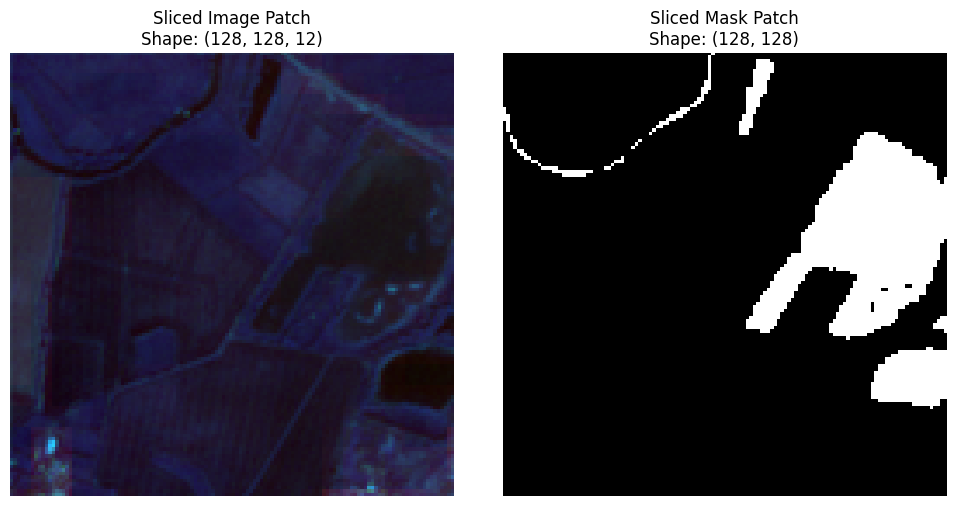

In [15]:
# Preparare the Images for visualization 
# By Grabing the 3 channels only

rgb_display = img_arr[:, :, :3].astype(np.float32)
rgb_display = (rgb_display - np.min(rgb_display)) / (np.max(rgb_display) - np.min(rgb_display) + 1e-8)

# 5. Plot the side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(rgb_display)
axes[0].set_title(f"Sliced Image Patch\nShape: {img_arr.shape}")
axes[0].axis('off')

axes[1].imshow(mask_arr, cmap='gray')
axes[1].set_title(f"Sliced Mask Patch\nShape: {mask_arr.shape}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [16]:
len(os.listdir(IMAGES_DIR))

7362

In [17]:
len(os.listdir(MASKS_DIR))

7512

# Fix the mismatch between the images count and masks count

In [18]:
# GET The Files Full Paths
train_img_files = [f for f in sorted(os.listdir(IMAGES_DIR)) if f.endswith(".tif")]
train_mask_files = [f for f in sorted(os.listdir(MASKS_DIR)) if f.endswith(".png")]

print(len(train_img_files), len(train_mask_files))

7362 7512


In [19]:
# Take the file name without the extension (.tif) or (.png)
img_basenames = set([os.path.splitext(f)[0] for f in train_img_files])
mask_basenames = set([os.path.splitext(f)[0] for f in train_mask_files])
img_basenames


{'new_path_490_1',
 'new_path_915_2',
 'new_path_952_1',
 'new_path_681_1',
 'new_path_1418_2',
 'new_path_1109_1',
 'new_path_1145_1',
 'new_path_563_2',
 'new_path_1673_3',
 'new_path_1485_3',
 'new_path_811_0',
 'new_path_144_1',
 'new_path_195_1',
 'new_path_1496_3',
 'new_path_1361_0',
 'new_path_1307_2',
 'new_path_415_3',
 'new_path_541_3',
 'new_path_1399_2',
 'new_path_368_3',
 '46',
 'new_path_1541_1',
 'new_path_596_1',
 'new_path_983_0',
 'new_path_678_2',
 'new_path_39_2',
 'new_path_449_2',
 'new_path_909_1',
 'new_path_1186_2',
 'new_path_595_1',
 'new_path_884_0',
 'new_path_781_1',
 'new_path_1300_2',
 'new_path_580_1',
 'new_path_1171_3',
 'new_path_824_0',
 'new_path_1733_3',
 'new_path_1535_3',
 'new_path_998_2',
 '300',
 '44',
 'new_path_1267_1',
 'new_path_1096_2',
 'new_path_1517_2',
 '62',
 'new_path_382_1',
 'new_path_389_2',
 'new_path_1357_1',
 'new_path_889_2',
 'new_path_1233_1',
 '132',
 'new_path_363_0',
 'new_path_516_3',
 'new_path_623_0',
 'new_path_95

In [ ]:
missing_masks = img_basenames - mask_basenames
missing_images = mask_basenames - img_basenames
print(f"Missing Masks: {len(missing_masks)}")
print(f"Missing images: {len(missing_images)}")

Missing Masks: 0
Missing images: 150


In [21]:
valid_basenames = img_basenames.intersection(mask_basenames)
print(f"Valid Basenames: {len(valid_basenames)}")

Valid Basenames: 7362


In [22]:
# Rebuild the lists using ONLY the valid pairs, and SORT them so they align perfectly!
train_img_files = sorted([f"{name}.tif" for name in valid_basenames])
train_mask_files = sorted([f"{name}.png" for name in valid_basenames])
len(train_img_files) == len(train_mask_files)

True

In [23]:
# Create a Folder of preprocessed data after remove the mismatch images
preprocessing_img_dir = "//mnt/d/01_Projects/CV/Water_Segmentation/Data/preprocessed_data/images/"
preprocessing_mask_dir = "//mnt/d/01_Projects/CV/Water_Segmentation/Data/preprocessed_data/labels/"
os.makedirs(preprocessing_img_dir, exist_ok=True)
os.makedirs(preprocessing_mask_dir, exist_ok=True)

In [24]:
# Create a copy of the matched images and masks into teh preprocessed folder

for name in tqdm(valid_basenames):
    # Define the orignal raw data
    raw_img_path = os.path.join(IMAGES_DIR, f"{name}.tif")
    raw_mask_path = os.path.join(MASKS_DIR, f"{name}.png")

    # Define the new destination
    new_img_path = os.path.join(preprocessing_img_dir, f"{name}.tif")
    new_mask_path = os.path.join(preprocessing_mask_dir, f"{name}.png")

    # Copy the files from the raw path to the new path 
    shutil.copy(raw_img_path, new_img_path)
    shutil.copy(raw_mask_path, new_mask_path)


  0%|          | 0/7362 [00:00<?, ?it/s]

100%|██████████| 7362/7362 [12:26<00:00,  9.86it/s]  
